--- Testing with N=12 ---
Binary Vector: [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1]

Dominating Polynomial Coefficients (d_0 ... d_N):
[0, 1, 11, 55, 289, 649, 867, 780, 494, 220, 66, 12, 1]

Drawing graph...


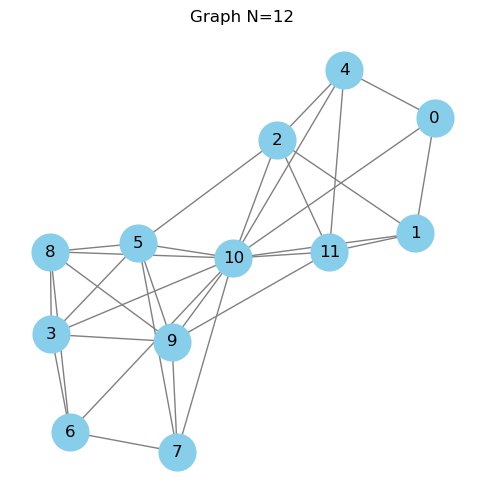


--- Testing Random Graph N=10 ---
Coefficients: [0, 0, 4, 47, 157, 235, 208, 120, 45, 10, 1]


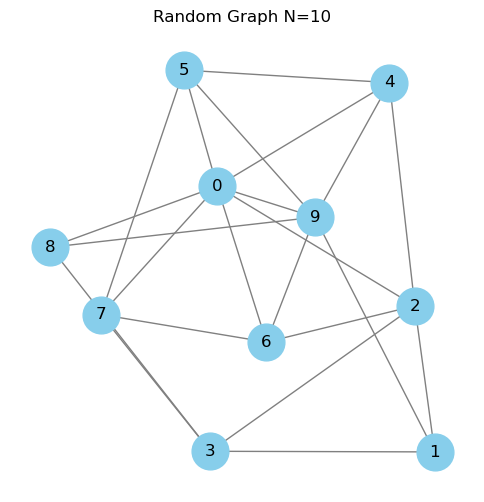

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# Helper: Bitmask Neighborhood Generation
# ==========================================
def get_closed_neighborhoods(n: int, bin_vec: list[int]) -> list[int]:
    """
    Converts the binary vector representation into a list of bitmasks.
    Each bitmask at index 'i' represents the closed neighborhood of vertex 'i'
    (the vertex itself + its neighbors).
    
    Args:
        n: Number of vertices.
        bin_vec: Flat binary vector representing the upper triangular adjacency matrix.

    Returns:
        A list of integers acting as bitmasks.
    """
    # Initialize neighborhoods with the vertex itself (closed neighborhood condition).
    # Using standard Python ints (which handle arbitrary size automatically).
    # 0-indexed: vertex 0 is bit 0 (1 << 0).
    neighborhoods = [(1 << i) for i in range(n)]
    
    edge_idx = 0
    # Iterate through the upper triangular part corresponding to bin_vec
    for i in range(n):
        for j in range(i + 1, n):
            # If edge exists in the binary vector
            if bin_vec[edge_idx] == 1:
                # Add j to i's neighbor list and i to j's neighbor list
                mask_j = (1 << j)
                mask_i = (1 << i)
                
                neighborhoods[i] |= mask_j
                neighborhoods[j] |= mask_i
            edge_idx += 1
            
    return neighborhoods

# ==========================================
# Core Function: Dominating Polynomial
# ==========================================
def dominating_polynomial(n: int, bin_vec: list[int]) -> list[int]:
    """
    Calculates the dominating polynomial of the graph using brute force search 
    over all 2^N subsets.

    Args:
        n: Number of vertices.
        bin_vec: Flat binary vector representing the upper triangular adjacency matrix.

    Returns:
        The coefficients array [d_0, d_1, ..., d_N], where d_k is the count
        of dominating sets of size k.
    """
    # Don't run brute force if N is too large
    if n > 22:
         raise ValueError(f"N={n} is too large for brute force dominating polynomial calculation.")

    neighborhoods = get_closed_neighborhoods(n, bin_vec)
    
    # Coefficients array, indexed by cardinality (size 0 to N)
    coeffs = [0] * (n + 1)
    
    # Target mask is all 1s (representing the set of all vertices V needed to be covered)
    full_mask = (1 << n) - 1
    
    # Iterate through all 2^N subsets from 0 to 2^N - 1
    # 'i' represents the bitmask of the current subset S being tested
    for subset_mask in range(1 << n):
        # Check if subset represented by 'subset_mask' is a dominating set.
        # A subset S is dominating if the union of closed neighborhoods of v \in S equals V.
        
        union_of_neighborhoods = 0
        temp_mask = subset_mask
        v_idx = 0
        
        # Iterate through the bits representing vertices in the subset
        while temp_mask > 0:
            # If vertex v_idx is in the subset
            if (temp_mask & 1) == 1:
                union_of_neighborhoods |= neighborhoods[v_idx]
            temp_mask >>= 1
            v_idx += 1
        
        # If the union covers all vertices, it is a dominating set
        if union_of_neighborhoods == full_mask:
            # Count set bits to get cardinality of the subset
            cardinality = bin(subset_mask).count('1')
            coeffs[cardinality] += 1
            
    return coeffs

# ==========================================
# Drawing Function
# ==========================================
def draw_graph_from_bin_vec(n: int, bin_vec: list[int], title="Graph Visualization"):
    """
    Reconstructs the graph from the binary vector and plots it using networkx and matplotlib.
    """
    # Validate input length
    expected_len = (n * (n - 1)) // 2
    if len(bin_vec) != expected_len:
         print(f"Warning: Binary vector length {len(bin_vec)} does not match expected length {expected_len} for N={n}.")

    G = nx.Graph()
    # Add nodes 0 to N-1
    G.add_nodes_from(range(n))

    edge_idx = 0
    # Reconstruct edges exactly matching the logic in get_closed_neighborhoods
    for i in range(n):
        for j in range(i + 1, n):
            if bin_vec[edge_idx] == 1:
                G.add_edge(i, j)
            edge_idx += 1

    # Drawing configuration
    plt.figure(figsize=(6, 6))
    # Spring layout attempts to position nodes so edges are readable
    pos = nx.spring_layout(G, seed=42) 
    
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=700)
    nx.draw_networkx_edges(G, pos, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=12, font_family="sans-serif")
    
    plt.title(title)
    plt.axis('off') # Hide axis border
    plt.show()

# ==========================================
# Example Usage
# ==========================================
if __name__ == '__main__':
    # Configuration (Must match the Julia N=12 example for comparison)

    
    # Example 1: A specific graph (a path 0-1-2-3)
    # Edges: (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)
    # Path indices: 0,    _,     _,     1,     _,     2
    #sample_bin_vec = [1, 0, 0, 1, 0, 1]
    #sample_bin_vec = [1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1]
    # sample_bin_vec = [0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0]
    # sample_bin_vec = [0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1]
    sample_bin_vec = [1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,1,1,0,1,1,0,1,1,1,0,0,0,0,0,0,1,1,0,1,1,1,1,0,1,1,0,1,0,0,1,1,0,1,1,0,1,1,1]
    num_possible_edges = len(sample_bin_vec) #(N_vertices * (N_vertices - 1)) // 2
    N_vertices = int((1 + (1+ 8 * num_possible_edges)**(1/2) ) / 2)
    # y = x(x-1)/2.  x^2 - x = 2y.  x^2 - x - 2y = 0.  x = 1 \pm sqrt(1 +8y) / 2
    #  example.  num_edges = y = 3, get x = (1 + sqrt(25))/2 = (1+5)/2 = 3.
    
    print(f"--- Testing with N={N_vertices} ---")
    print(f"Binary Vector: {sample_bin_vec}")

    # 1. Calculate Dominating Polynomial
    try:
        poly_coeffs = dominating_polynomial(N_vertices, sample_bin_vec)
        print(f"\nDominating Polynomial Coefficients (d_0 ... d_N):")
        print(poly_coeffs)
        # For P4 path, expected: [0, 0, 3, 4, 1] corresponding to x^4 + 4x^3 + 3x^2
    except ValueError as e:
        print(e)

    # 2. Draw the graph
    print("\nDrawing graph...")
    draw_graph_from_bin_vec(N_vertices, sample_bin_vec, title=f"Graph N={N_vertices}")
    
    # Example 2: Larger random graph
    import random
    N_large = 10
    num_edges_large = (N_large * (N_large - 1)) // 2
    random_vec = [random.choice([0, 1]) for _ in range(num_edges_large)]
    
    print(f"\n--- Testing Random Graph N={N_large} ---")
    coeffs_large = dominating_polynomial(N_large, random_vec)
    print(f"Coefficients: {coeffs_large}")
    draw_graph_from_bin_vec(N_large, random_vec, title=f"Random Graph N={N_large}")